In [1]:
# how to import python files in other directory
import os
import sys
os.chdir("../../")
now_dir = os.getcwd()
print(now_dir)

# the path appended to sys.path is an absolute path
sys.path.append(os.path.join(now_dir, r'models\util'))
sys.path.append(os.path.join(now_dir, r'models\spindle_3'))

d:\mynew\demo_all


读取 3359 个纺锤波
过滤后 3359 个纺锤波
参数值: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.0625, 1.1, 1.125, 1.1875, 1.2, 1.25, 1.3, 1.3125, 1.375, 1.4, 1.4375, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0]

汇总统计:
    cie_c2tsc0x8_Jrt0x6  fast_total_mean  fast_total_std  fast_coupled_mean  \
0                0.1000             6.35        1.225819               4.80   
1                0.2000             6.80        1.436370               4.85   
2                0.3000             6.45        1.761429               5.10   
3                0.4000             6.35        2.207046               4.55   
4                0.5000             6.45        1.986136               4.55   
5                0.6000             6.20        1.704483               4.40   
6                0.7000             5.60        1.957442               3.95   
7                0.8000             5.90        1.372665               4.10   
8                0.9000             5.80        2.238420               3.95   
9                1

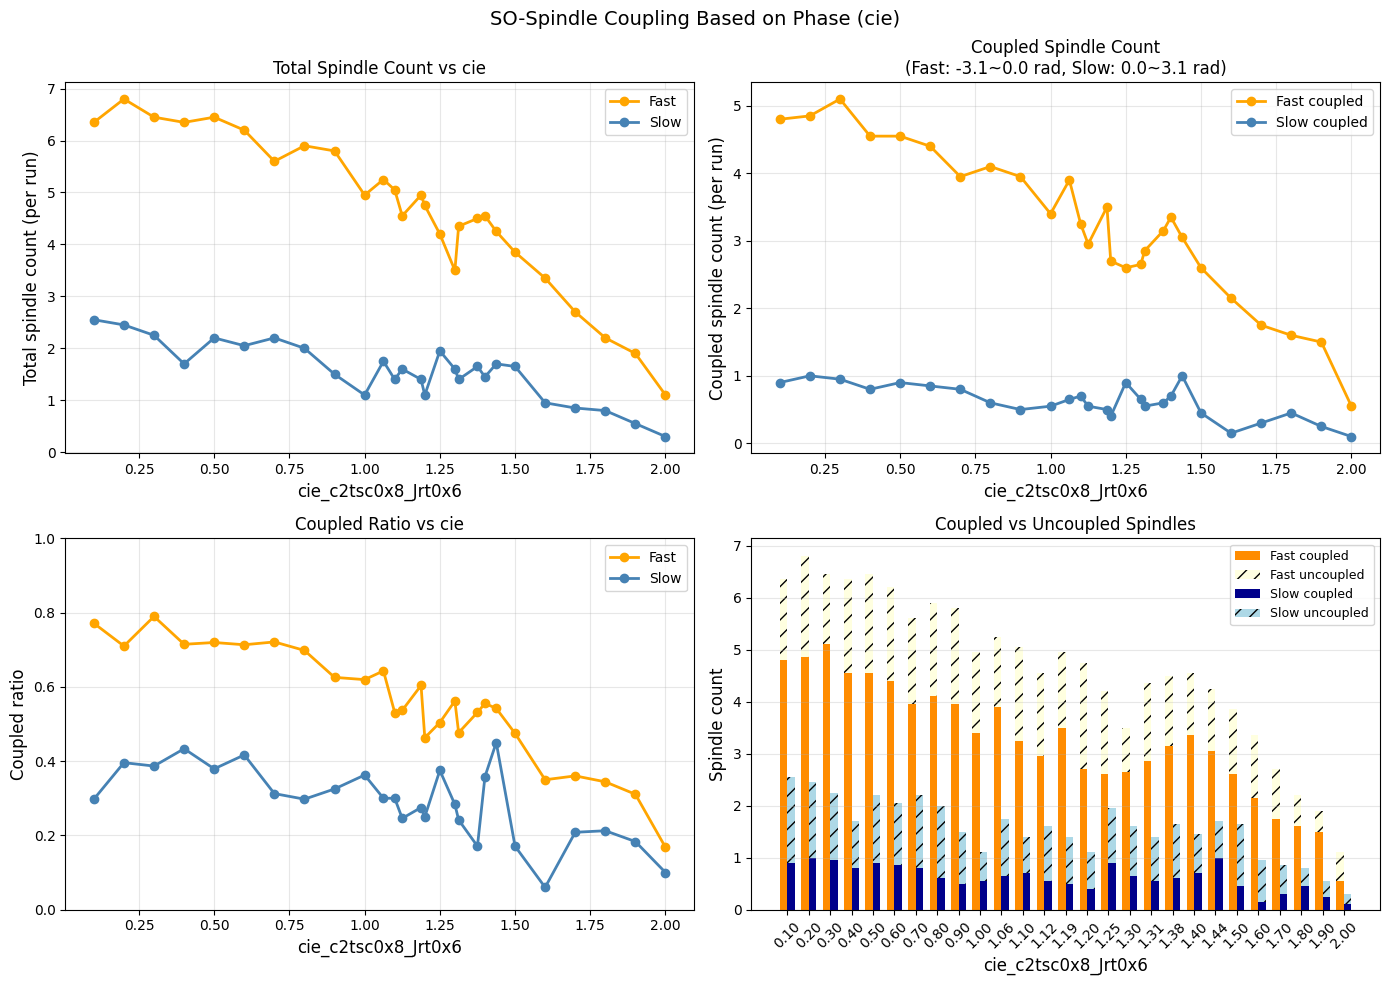


统计摘要 (cie)

0.100:
  Fast: total=6.3±1.2, coupled=4.8±1.2, ratio=0.771±0.192
  Slow: total=2.5±1.4, coupled=0.9±1.0, ratio=0.297±0.347

0.200:
  Fast: total=6.8±1.4, coupled=4.8±1.7, ratio=0.710±0.204
  Slow: total=2.5±0.9, coupled=1.0±1.0, ratio=0.396±0.360

0.300:
  Fast: total=6.5±1.8, coupled=5.1±1.8, ratio=0.790±0.189
  Slow: total=2.2±1.2, coupled=0.9±0.9, ratio=0.387±0.367

0.400:
  Fast: total=6.3±2.2, coupled=4.5±1.9, ratio=0.715±0.156
  Slow: total=1.7±0.9, coupled=0.8±0.6, ratio=0.433±0.360

0.500:
  Fast: total=6.5±2.0, coupled=4.5±1.3, ratio=0.719±0.127
  Slow: total=2.2±1.3, coupled=0.9±0.9, ratio=0.379±0.394

0.600:
  Fast: total=6.2±1.7, coupled=4.4±1.7, ratio=0.713±0.213
  Slow: total=2.0±1.5, coupled=0.8±0.8, ratio=0.417±0.396

0.700:
  Fast: total=5.6±2.0, coupled=4.0±1.6, ratio=0.721±0.215
  Slow: total=2.2±1.3, coupled=0.8±1.0, ratio=0.312±0.383

0.800:
  Fast: total=5.9±1.4, coupled=4.1±1.4, ratio=0.698±0.218
  Slow: total=2.0±1.4, coupled=0.6±0.7, ratio=0.297±0.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import circmean, circstd

# ========== 参数设置 ==========
CSV_PATH = "data/analysis_data/spindles_cie_c2tsc0x8_Jrt0x6_explore_valid_limited.csv"
PARAM_NAME = "cie_c2tsc0x8_Jrt0x6"
PARAM_RANGE = (0.1, 2.0)

# ========== 定义耦合相位区间 ==========
# 快纺锤波：-π 到 0（Up state 附近）
# 慢纺锤波：0 到 π（Down state 附近）
FAST_PHASE_LOW = -np.pi
FAST_PHASE_HIGH = 0
SLOW_PHASE_LOW = 0
SLOW_PHASE_HIGH = np.pi

# ========== 读取数据 ==========
df = pd.read_csv(CSV_PATH)
print(f"读取 {len(df)} 个纺锤波")

# 过滤参数范围
df = df[(df[PARAM_NAME] >= PARAM_RANGE[0]) & (df[PARAM_NAME] <= PARAM_RANGE[1])]
print(f"过滤后 {len(df)} 个纺锤波")

# 获取参数值
param_values = sorted(df[PARAM_NAME].unique())
print(f"参数值: {param_values}")

# ========== 按 seed 和参数分组统计 ==========
def is_coupled(phase, spindle_type):
    """判断纺锤波是否与 SO 耦合（基于相位区间）"""
    if spindle_type == 'fast':
        return FAST_PHASE_LOW <= phase <= FAST_PHASE_HIGH
    else:  # slow
        return SLOW_PHASE_LOW <= phase <= SLOW_PHASE_HIGH

results = []

for param_val in param_values:
    for seed in df['seed'].unique():
        subset = df[(df[PARAM_NAME] == param_val) & (df['seed'] == seed)]
        
        # 快纺锤波
        fast_subset = subset[subset['type'] == 'fast']
        fast_total = len(fast_subset)
        fast_phases = fast_subset['phase_at_peak'].dropna().values
        fast_coupled = sum(1 for p in fast_phases if is_coupled(p, 'fast'))
        
        # 慢纺锤波
        slow_subset = subset[subset['type'] == 'slow']
        slow_total = len(slow_subset)
        slow_phases = slow_subset['phase_at_peak'].dropna().values
        slow_coupled = sum(1 for p in slow_phases if is_coupled(p, 'slow'))
        
        results.append({
            PARAM_NAME: param_val,
            'seed': seed,
            'fast_total': fast_total,
            'fast_coupled': fast_coupled,
            'fast_ratio': fast_coupled / fast_total if fast_total > 0 else 0,
            'slow_total': slow_total,
            'slow_coupled': slow_coupled,
            'slow_ratio': slow_coupled / slow_total if slow_total > 0 else 0,
        })

df_results = pd.DataFrame(results)

# ========== 按参数汇总 ==========
summary = df_results.groupby(PARAM_NAME).agg(
    fast_total_mean=('fast_total', 'mean'),
    fast_total_std=('fast_total', 'std'),
    fast_coupled_mean=('fast_coupled', 'mean'),
    fast_coupled_std=('fast_coupled', 'std'),
    fast_ratio_mean=('fast_ratio', 'mean'),
    fast_ratio_std=('fast_ratio', 'std'),
    slow_total_mean=('slow_total', 'mean'),
    slow_total_std=('slow_total', 'std'),
    slow_coupled_mean=('slow_coupled', 'mean'),
    slow_coupled_std=('slow_coupled', 'std'),
    slow_ratio_mean=('slow_ratio', 'mean'),
    slow_ratio_std=('slow_ratio', 'std'),
    n_seeds=('seed', 'count'),
).reset_index()

print("\n汇总统计:")
print(summary)

# ========== 画图 ==========
param_vals = summary[PARAM_NAME].values
fast_total = summary['fast_total_mean'].values
fast_coupled = summary['fast_coupled_mean'].values
fast_ratio = summary['fast_ratio_mean'].values
slow_total = summary['slow_total_mean'].values
slow_coupled = summary['slow_coupled_mean'].values
slow_ratio = summary['slow_ratio_mean'].values

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 图1：纺锤波总数随参数变化
ax = axes[0, 0]
ax.plot(param_vals, fast_total, 'o-', color='orange', linewidth=2, markersize=6, label='Fast')
ax.plot(param_vals, slow_total, 'o-', color='steelblue', linewidth=2, markersize=6, label='Slow')
ax.set_xlabel(PARAM_NAME, fontsize=12)
ax.set_ylabel('Total spindle count (per run)', fontsize=12)
ax.set_title('Total Spindle Count vs cie', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# 图2：耦合数量随参数变化
ax = axes[0, 1]
ax.plot(param_vals, fast_coupled, 'o-', color='orange', linewidth=2, markersize=6, label='Fast coupled')
ax.plot(param_vals, slow_coupled, 'o-', color='steelblue', linewidth=2, markersize=6, label='Slow coupled')
ax.set_xlabel(PARAM_NAME, fontsize=12)
ax.set_ylabel('Coupled spindle count (per run)', fontsize=12)
ax.set_title(f'Coupled Spindle Count\n(Fast: {FAST_PHASE_LOW:.1f}~{FAST_PHASE_HIGH:.1f} rad, Slow: {SLOW_PHASE_LOW:.1f}~{SLOW_PHASE_HIGH:.1f} rad)', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# 图3：耦合比例随参数变化
ax = axes[1, 0]
ax.plot(param_vals, fast_ratio, 'o-', color='orange', linewidth=2, markersize=6, label='Fast')
ax.plot(param_vals, slow_ratio, 'o-', color='steelblue', linewidth=2, markersize=6, label='Slow')
ax.set_xlabel(PARAM_NAME, fontsize=12)
ax.set_ylabel('Coupled ratio', fontsize=12)
ax.set_title('Coupled Ratio vs cie', fontsize=12)
ax.set_ylim(0, 1)
ax.legend()
ax.grid(True, alpha=0.3)

# 图4：堆叠柱状图（耦合 vs 未耦合）
ax = axes[1, 1]
x = np.arange(len(param_vals))
width = 0.35

# 快纺锤波
fast_uncoupled = fast_total - fast_coupled
slow_uncoupled = slow_total - slow_coupled

ax.bar(x - width/2, fast_coupled, width, color='darkorange', label='Fast coupled')
ax.bar(x - width/2, fast_uncoupled, width, bottom=fast_coupled, 
       color='lightyellow', label='Fast uncoupled', hatch='//')
ax.bar(x + width/2, slow_coupled, width, color='darkblue', label='Slow coupled')
ax.bar(x + width/2, slow_uncoupled, width, bottom=slow_coupled, 
       color='lightblue', label='Slow uncoupled', hatch='//')

ax.set_xlabel(PARAM_NAME, fontsize=12)
ax.set_ylabel('Spindle count', fontsize=12)
ax.set_title('Coupled vs Uncoupled Spindles', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels([f'{v:.2f}' for v in param_vals], rotation=45)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle(f'SO-Spindle Coupling Based on Phase (cie)', fontsize=14)
plt.tight_layout()
plt.show()

# ========== 打印统计摘要 ==========
print("\n" + "="*60)
print("统计摘要 (cie)")
print("="*60)

for _, row in summary.iterrows():
    print(f"\n{row[PARAM_NAME]:.3f}:")
    print(f"  Fast: total={row['fast_total_mean']:.1f}±{row['fast_total_std']:.1f}, "
          f"coupled={row['fast_coupled_mean']:.1f}±{row['fast_coupled_std']:.1f}, "
          f"ratio={row['fast_ratio_mean']:.3f}±{row['fast_ratio_std']:.3f}")
    print(f"  Slow: total={row['slow_total_mean']:.1f}±{row['slow_total_std']:.1f}, "
          f"coupled={row['slow_coupled_mean']:.1f}±{row['slow_coupled_std']:.1f}, "
          f"ratio={row['slow_ratio_mean']:.3f}±{row['slow_ratio_std']:.3f}")

### 生成不同cie的npy

In [15]:
import numpy as np
import runModels as rm
import defaultParameters as dp
import os

def run_parameter_sweep(config):
    """
    运行参数扫描
    config: 字典，包含所有参数
    """
    # 解包配置
    n_runs = config['n_runs']
    c2tsc = config['c2tsc']              # 定值
    scale2 = config['scale2']            # 定值
    Jet = config['Jet']                    # 定值
    Jer = config['Jer']                    # 定值
    param_name = config['param_name']    # 要扫描的参数名
    param_list = config['param_list']    # 要扫描的参数值列表
    data_dir = config['data_dir']        # 保存目录
    
    # 创建保存目录
    os.makedirs(data_dir, exist_ok=True)
    
    # 统计已完成文件（跳过已存在的）
    existing_files = set()
    for f in os.listdir(data_dir):
        if f.endswith(".npy"):
            existing_files.add(f)
    
    total_tasks = len(param_list) * n_runs
    completed = len([f for f in existing_files if param_name in f])
    print(f"总任务数: {total_tasks}, 已完成: {completed}, 待运行: {total_tasks - completed}")
    
    for param_val in param_list:
        for seed in range(1, n_runs + 1):
            # 生成文件名
            filename = f"c2tsc_{c2tsc:.4f}_scale2_{scale2:.4f}_{param_name}_{param_val:.4f}_seed_{seed}.npy"
            save_path = os.path.join(data_dir, filename)
            
            # 如果文件已存在，跳过
            if filename in existing_files:
                print(f"跳过: {filename}")
                continue
            
            # 加载默认参数并修改
            params = dp.loadDefaultParams(seed)
            params["c2tsc"] = c2tsc
            params["scale2"] = scale2
            params["Jet"] = Jet
            params["Jer"] = Jer
            params["Jrt"] = -0.6
            params[param_name] = param_val
            
            # 运行模型
            try:
                t, Q_t, Q_r, V_t, V_r, Q_e, Q_i, V_e, V_i, c, V_e2, V_i2, c2 = rm.runModels(manual_params=params)
            except Exception as e:
                print(f"模型运行失败: {filename}, 错误: {e}")
                continue
            
            # 保存 raw 信号
            np.save(save_path, {
                "t": t, "V_e": V_e, "V_i": V_i, 
                "Q_e": Q_e, "Q_i": Q_i, 
                "V_t": V_t, "V_r": V_r, 
                "Q_t": Q_t, "Q_r": Q_r,
                "c2tsc": c2tsc,
                "scale2": scale2,
                param_name: param_val,
                "seed": seed
            })
            print(f"Saved: {param_name}={param_val:.4f}, seed={seed}")

# ========== 使用示例 ==========

# 示例1：扫描 mue_ext_mean
config_mue = {
    'n_runs': 20,
    'c2tsc': 0.8,
    'scale2': 0.0013,
    'param_name': 'mue_ext_mean',
    'param_list': np.linspace(2.3, 3.1, 15),
    'data_dir': "data/raw_data_explore_mueextmean",
}

# 示例2：扫描 tau_ou
config_tauou = {
    'n_runs': 20,
    'c2tsc': 0.8,
    'scale2': 0.0013,
    'param_name': 'tau_ou',
    'param_list': np.linspace(5, 12, 30),
    'data_dir': "data/raw_data_explore_tauou",
}

# 示例3：扫描 tau_se
config_tause = {
    'n_runs': 20,
    'c2tsc': 0.8,
    'scale2': 0.0013,
    'param_name': 'tau_se',
    'param_list': np.linspace(1, 8, 15),
    'data_dir': "data/raw_data_explore_tause",
}

config_cee = {
    'n_runs': 20,
    'c2tsc': 0.8,
    'scale2': 0.0013,
    'param_name': 'cee',
    'param_list': np.concatenate([np.linspace(0.2, 1, 15), np.linspace(1, 1.9, 15)]),
    'data_dir': "data/raw_data_explore_cee",
}

config_cie = {
    'n_runs': 20,
    'c2tsc': 0.8,
    'scale2': 0.0005,
    'Jet': 78.2,
    'Jer': 162.0,
    'param_name': 'cie',
    'param_list': np.linspace(1.5, 2.0, 6),
    'data_dir': "data/raw_data_explore_cie_c2tsc0x8_Jrt0x6",
}

# 运行（取消注释需要的）
run_parameter_sweep(config_cie)

总任务数: 120, 已完成: 440, 待运行: -320
跳过: c2tsc_0.8000_scale2_0.0005_cie_1.5000_seed_1.npy
跳过: c2tsc_0.8000_scale2_0.0005_cie_1.5000_seed_2.npy
跳过: c2tsc_0.8000_scale2_0.0005_cie_1.5000_seed_3.npy
跳过: c2tsc_0.8000_scale2_0.0005_cie_1.5000_seed_4.npy
跳过: c2tsc_0.8000_scale2_0.0005_cie_1.5000_seed_5.npy
跳过: c2tsc_0.8000_scale2_0.0005_cie_1.5000_seed_6.npy
跳过: c2tsc_0.8000_scale2_0.0005_cie_1.5000_seed_7.npy
跳过: c2tsc_0.8000_scale2_0.0005_cie_1.5000_seed_8.npy
跳过: c2tsc_0.8000_scale2_0.0005_cie_1.5000_seed_9.npy
跳过: c2tsc_0.8000_scale2_0.0005_cie_1.5000_seed_10.npy
跳过: c2tsc_0.8000_scale2_0.0005_cie_1.5000_seed_11.npy
跳过: c2tsc_0.8000_scale2_0.0005_cie_1.5000_seed_12.npy
跳过: c2tsc_0.8000_scale2_0.0005_cie_1.5000_seed_13.npy
跳过: c2tsc_0.8000_scale2_0.0005_cie_1.5000_seed_14.npy
跳过: c2tsc_0.8000_scale2_0.0005_cie_1.5000_seed_15.npy
跳过: c2tsc_0.8000_scale2_0.0005_cie_1.5000_seed_16.npy
跳过: c2tsc_0.8000_scale2_0.0005_cie_1.5000_seed_17.npy
跳过: c2tsc_0.8000_scale2_0.0005_cie_1.5000_seed_18.npy
跳过: c2

d:\mynew\demo_all\models\spindle_3\timeIntegration.py:469: RuntimeWarning: overflow encountered in double_scalars
  siev_rhs = ((1 - siem)**2 * z2ie + (z2ie - 2*tau_se*(z1ie+1))*siev)/tau_se**2
d:\mynew\demo_all\models\spindle_3\timeIntegration.py:488: RuntimeWarning: invalid value encountered in add
  k2 = rhs(i, y + 0.5*scale*k1)
d:\mynew\demo_all\models\spindle_3\timeIntegration.py:463: RuntimeWarning: overflow encountered in double_scalars
  siem_rhs = ((1 - siem) * z1ie - siem)/tau_se


Saved: cie=1.6000, seed=2
Saved: cie=1.6000, seed=3
Saved: cie=1.6000, seed=4
Saved: cie=1.6000, seed=5


d:\mynew\demo_all\models\spindle_3\timeIntegration.py:523: RuntimeWarning: overflow encountered in double_scalars
  + sigmai_ext**2), 0.0
d:\mynew\demo_all\models\spindle_3\timeIntegration.py:429: RuntimeWarning: overflow encountered in double_scalars
  + sigmai_ext**2), 0.0
d:\mynew\demo_all\models\spindle_3\timeIntegration.py:469: RuntimeWarning: invalid value encountered in double_scalars
  siev_rhs = ((1 - siem)**2 * z2ie + (z2ie - 2*tau_se*(z1ie+1))*siev)/tau_se**2


Saved: cie=1.6000, seed=6
Saved: cie=1.6000, seed=7


d:\mynew\demo_all\models\spindle_3\timeIntegration.py:491: RuntimeWarning: invalid value encountered in add
  y_next = y + scale*(k1 + 2*k2 + 2*k3 + k4)/6.0


Saved: cie=1.6000, seed=8
Saved: cie=1.6000, seed=9
Saved: cie=1.6000, seed=10
Saved: cie=1.6000, seed=11
Saved: cie=1.6000, seed=12
Saved: cie=1.6000, seed=13
Saved: cie=1.6000, seed=14
Saved: cie=1.6000, seed=15
Saved: cie=1.6000, seed=16
Saved: cie=1.6000, seed=17
Saved: cie=1.6000, seed=18
Saved: cie=1.6000, seed=19
Saved: cie=1.6000, seed=20
Saved: cie=1.7000, seed=1
Saved: cie=1.7000, seed=2
Saved: cie=1.7000, seed=3
Saved: cie=1.7000, seed=4
Saved: cie=1.7000, seed=5
Saved: cie=1.7000, seed=6
Saved: cie=1.7000, seed=7
Saved: cie=1.7000, seed=8
Saved: cie=1.7000, seed=9
Saved: cie=1.7000, seed=10
Saved: cie=1.7000, seed=11
Saved: cie=1.7000, seed=12
Saved: cie=1.7000, seed=13
Saved: cie=1.7000, seed=14
Saved: cie=1.7000, seed=15
Saved: cie=1.7000, seed=16
Saved: cie=1.7000, seed=17
Saved: cie=1.7000, seed=18
Saved: cie=1.7000, seed=19
Saved: cie=1.7000, seed=20
Saved: cie=1.8000, seed=1
Saved: cie=1.8000, seed=2
Saved: cie=1.8000, seed=3
Saved: cie=1.8000, seed=4
Saved: cie=1.800

### spindles for param anlysis (spindles_param_explore_valid_limited.csv)
- param = cie
- c2tsc = 1; scale2 = 0.0005 / c2tsc=0.8; Jrt=-0.6
- param -> fast/slow spindles

### 新增wax&wane

In [18]:
import numpy as np
import pandas as pd
import yasa
import glob
from scipy.signal import hilbert
import xarray as xr
from neurolib.utils.signal import Signal, RatesSignal
import os

# ========== 只需要改这两行 ==========
DATA_FOLDER = "cie_c2tsc0x8_Jrt0x6"      # 数据文件夹名
PARAM_NAME = "cie_c2tsc0x8_Jrt0x6"       # 参数名
PARAM_RANGE = (0.1, 2.0)                 # 参数范围 (min, max)
# =================================

RAW_DATA_DIR = f"data/raw_data_explore_{DATA_FOLDER}"
OUTPUT_PREFIX = f"spindles_{DATA_FOLDER}"

def get_phase_and_envelope(signal, filter_args, pad=None):
    assert isinstance(signal, Signal)
    phase = signal.detrend(inplace=False)
    if pad:
        phase.pad(how_much=pad, in_seconds=True, padding_type="reflect", side="both")
    phase.filter(**filter_args)
    filtered = phase.data.values.copy()
    phase.hilbert_transform(return_as="phase_wrapped")
    if pad:
        phase.sel([phase.start_time + pad, phase.end_time - pad])
    analytic = hilbert(filtered)
    envelope = np.abs(analytic)
    return phase.data.values, filtered, envelope

def process_spindles(sp, spindle_type, params, t_mid, sf, t_min, t_max, envelope, slow_phase_masked, V_t=None):
    """
    处理纺锤波检测结果
    新增：从原始 V_t 中提取 start→peak 和 peak→end 的振幅
    """
    results = []
    if sp is None:
        return results
    
    df = sp.summary()
    for _, row in df.iterrows():
        start_time = row["Start"]
        peak_time = row["Peak"]
        end_time = row["End"]
        overall_amplitude = row["Amplitude"]  # YASA 计算的整体振幅
        
        start_idx_sample = int(start_time * sf)
        peak_idx_sample = int(peak_time * sf)
        end_idx_sample = int(end_time * sf)
        
        if not (t_min <= start_idx_sample <= t_max and t_min <= end_idx_sample <= t_max):
            continue
        
        start_idx = np.argmin(np.abs(t_mid - start_idx_sample))
        peak_idx = np.argmin(np.abs(t_mid - peak_idx_sample))
        end_idx = np.argmin(np.abs(t_mid - end_idx_sample))
        
        # ===== 从原始 V_t 中计算 start→peak 和 peak→end 的振幅 =====
        # 截取信号片段
        start_segment = V_t[start_idx_sample:peak_idx_sample] if peak_idx_sample > start_idx_sample else np.array([0])
        end_segment = V_t[peak_idx_sample:end_idx_sample] if end_idx_sample > peak_idx_sample else np.array([0])
        
        # 计算各段的峰峰值振幅
        if len(start_segment) >= 2:
            start_to_peak_amp = np.max(start_segment) - np.min(start_segment)
        else:
            start_to_peak_amp = 0.0
        
        if len(end_segment) >= 2:
            peak_to_end_amp = np.max(end_segment) - np.min(end_segment)
        else:
            peak_to_end_amp = 0.0
        
        phase_start = slow_phase_masked[start_idx]
        phase_peak = slow_phase_masked[peak_idx]
        phase_end = slow_phase_masked[end_idx]
        
        results.append({
            **params,
            "type": spindle_type,
            "start": start_time,
            "peak_time": peak_time,
            "end": end_time,
            "duration": row["Duration"],
            "frequency": row["Frequency"],
            "amplitude": overall_amplitude,              # 原有的整体振幅
            "start_to_peak_time": peak_time - start_time,
            "peak_to_end_time": end_time - peak_time,
            "start_to_peak_amp": start_to_peak_amp,      # 新增：上升段振幅
            "peak_to_end_amp": peak_to_end_amp,          # 新增：下降段振幅
            "phase_at_start": phase_start,
            "phase_at_peak": phase_peak,
            "phase_at_end": phase_end,
            "envelope_at_start": envelope[start_idx],
            "envelope_at_peak": envelope[peak_idx],
            "envelope_at_end": envelope[end_idx],
            "masked": np.isnan(phase_peak),
        })
    return results

# ========== 主程序 ==========
sf = 10000
remove_edges_samples = 20000
SW = {"low_freq": None, "high_freq": 3.0}
amplitude_threshold = 2

file_list = glob.glob(os.path.join(RAW_DATA_DIR, "*.npy"))
print(f"找到 {len(file_list)} 个文件")
print(f"限定 {PARAM_NAME} 范围: {PARAM_RANGE}")
print(f"输出前缀: {OUTPUT_PREFIX}")

all_spindles = []

for file_path in file_list:
    file_path = file_path.replace("\\", "/")
    filename = os.path.basename(file_path)
    parts = filename.replace(".npy", "").split("_")
    
    # 固定解析格式: c2tsc_{val}_scale2_{val}_{param}_{val}_seed_{val}
    c2tsc = float(parts[1])
    scale2 = float(parts[3])
    param_val = float(parts[5])
    seed = int(parts[7])
    
    # 过滤参数范围
    if not (PARAM_RANGE[0] <= param_val <= PARAM_RANGE[1]):
        continue
    
    print(f"Processing: {PARAM_NAME}={param_val:.4f}, seed={seed}")
    
    data = np.load(file_path, allow_pickle=True).item()
    t = data["t"]
    V_t = data["V_t"]
    V_e = data["V_e"]
    
    t_min = remove_edges_samples
    t_max = t[-1] - remove_edges_samples
    
    mask = (t >= t_min) & (t <= t_max)
    t_mid = t[mask]
    V_e_mid = V_e[mask]
    
    if len(t_mid) == 0:
        print(f"  警告：没有有效数据，跳过")
        continue
    
    results_df = pd.DataFrame({"ALN": V_e_mid}, index=t_mid / sf)
    results_df.index.name = "time"
    aln_xr = xr.DataArray(results_df["ALN"])
    aln_sig = RatesSignal(aln_xr)
    
    slow_phase, V_slow, envelope = get_phase_and_envelope(aln_sig, filter_args=SW, pad=0.0)
    
    mask_amplitude = envelope > amplitude_threshold
    slow_phase_masked = slow_phase.copy()
    slow_phase_masked[~mask_amplitude] = np.nan
    
    params = {PARAM_NAME: param_val, "c2tsc": c2tsc, "scale2": scale2, "seed": seed}
    
    # 传入 V_t 用于计算分段振幅
    sp_fast = yasa.spindles_detect(V_t, sf, freq_sp=(12,16), duration=(0.3,2))
    all_spindles.extend(process_spindles(sp_fast, "fast", params, t_mid, sf, t_min, t_max, envelope, slow_phase_masked, V_t))
    
    sp_slow = yasa.spindles_detect(V_t, sf, freq_sp=(8,12), duration=(0.3,2))
    all_spindles.extend(process_spindles(sp_slow, "slow", params, t_mid, sf, t_min, t_max, envelope, slow_phase_masked, V_t))
    
    print(f"  完成")

os.makedirs("data/analysis_data", exist_ok=True)
result_df = pd.DataFrame(all_spindles)
result_df.to_csv(f"data/analysis_data/{OUTPUT_PREFIX}_explore_limited.csv", index=False)

result_df_valid = result_df[~result_df['masked']].copy()
result_df_valid.to_csv(f"data/analysis_data/{OUTPUT_PREFIX}_explore_valid_limited.csv", index=False)

print(f"\n总共检测到 {len(result_df)} 个纺锤波")
print(f"相位有效: {len(result_df_valid)} 个")

# 打印新增字段示例
if len(result_df) > 0:
    print("\n新增字段示例（第一条记录）:")
    cols = ['start_to_peak_time', 'peak_to_end_time', 'start_to_peak_amp', 'peak_to_end_amp', 'amplitude']
    for col in cols:
        if col in result_df.columns:
            print(f"  {col}: {result_df[col].iloc[0]:.6f}")

找到 540 个文件
限定 cie_c2tsc0x8_Jrt0x6 范围: (0.1, 2.0)
输出前缀: spindles_cie_c2tsc0x8_Jrt0x6
Processing: cie_c2tsc0x8_Jrt0x6=0.1000, seed=1
Setting up low-pass filter at 3 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 3.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.00 Hz)
- Filter length: 16501 samples (1.650 sec)



[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


  完成
Processing: cie_c2tsc0x8_Jrt0x6=0.1000, seed=10
Setting up low-pass filter at 3 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 3.00 Hz


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.00 Hz)
- Filter length: 16501 samples (1.650 sec)



...

  完成
Processing: cie_c2tsc0x8_Jrt0x6=2.0000, seed=8
Setting up low-pass filter at 3 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 3.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.00 Hz)
- Filter length: 16501 samples (1.650 sec)



[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
10-Aug-26 12:46:08 | WARNING | No spindle were found in channel CHAN000.
10-Aug-26 12:46:08 | WARNING | No spindles were found in data. Returning None.
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:   

  完成
Processing: cie_c2tsc0x8_Jrt0x6=2.0000, seed=9
Setting up low-pass filter at 3 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 3.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.00 Hz)
- Filter length: 16501 samples (1.650 sec)



[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent work

  完成

总共检测到 3785 个纺锤波
相位有效: 3359 个

新增字段示例（第一条记录）:
  start_to_peak_time: 0.266000
  peak_to_end_time: 0.058800
  start_to_peak_amp: 5.845324
  peak_to_end_amp: 3.142178
  amplitude: 4.449508


### 为cie 画图

### 画图 新增wax&wane

加载文件: spindles_cie_c2tsc0x8_Jrt0x6_explore_valid_limited.csv
分析参数: cie_c2tsc0x8_Jrt0x6
检测到新增列: ['start_to_peak_time', 'peak_to_end_time', 'start_to_peak_amp', 'peak_to_end_amp']
cie_c2tsc0x8_Jrt0x6 值: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.0625, 1.1, 1.125, 1.1875, 1.2, 1.25, 1.3, 1.3125, 1.375, 1.4, 1.4375, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0]

按 seed 统计后的结果示例:
   cie_c2tsc0x8_Jrt0x6  seed  type  total_duration  count  mean_freq  \
0                  0.1     1  fast          1.7898      4  14.167210   
1                  0.1     1  slow          1.4544      3  10.246548   
2                  0.1     2  fast          3.5400      5  13.927045   
3                  0.1     2  slow          1.9203      4  10.640156   
4                  0.1     3  fast          3.8013      6  14.206275   

   std_freq  mean_duration  std_duration  mean_start_to_peak_time  \
0  0.305761       0.447450      0.179829                 0.166725   
1  0.498371       0.484800      0.078219                 

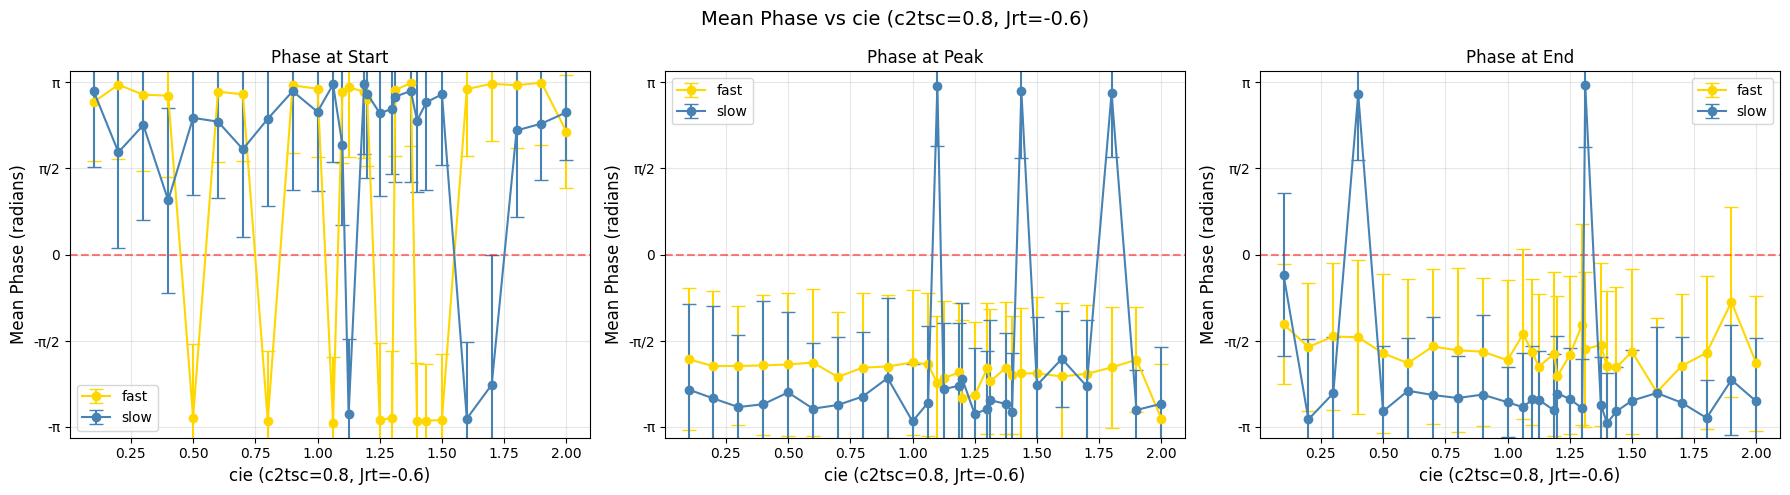

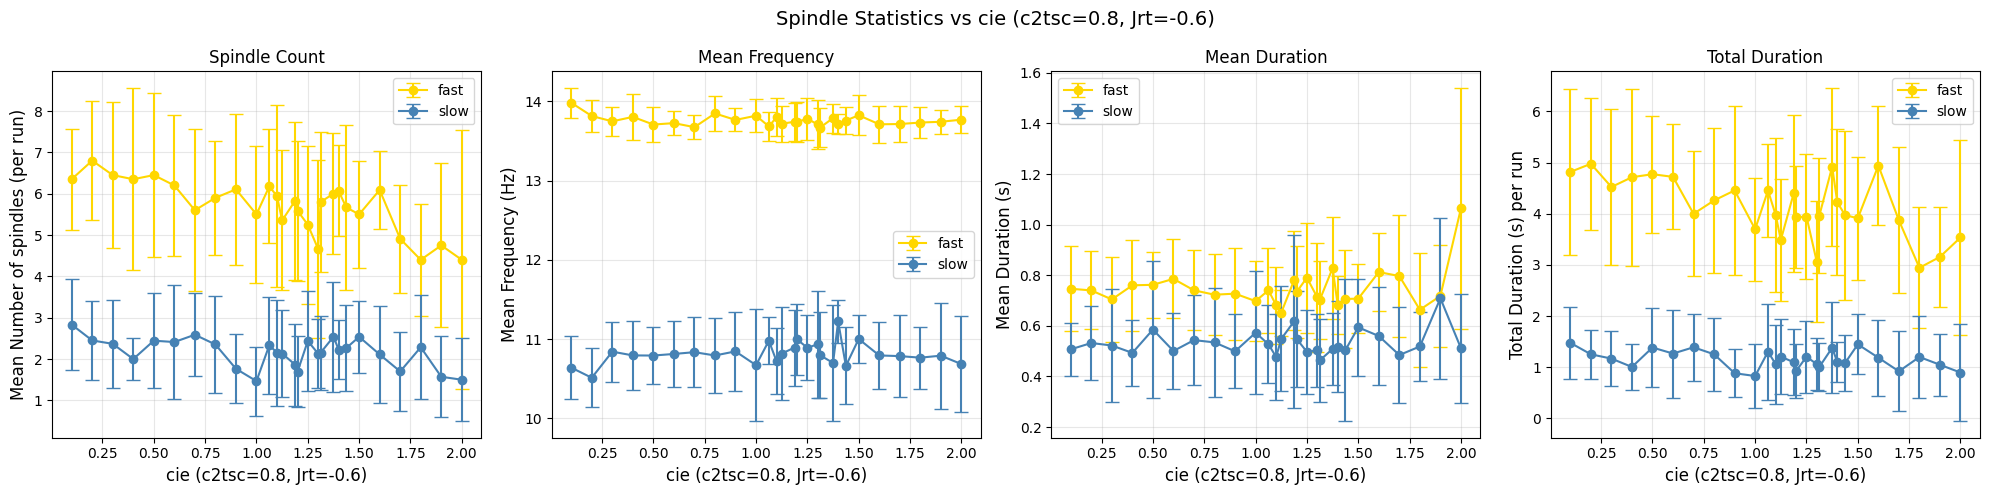

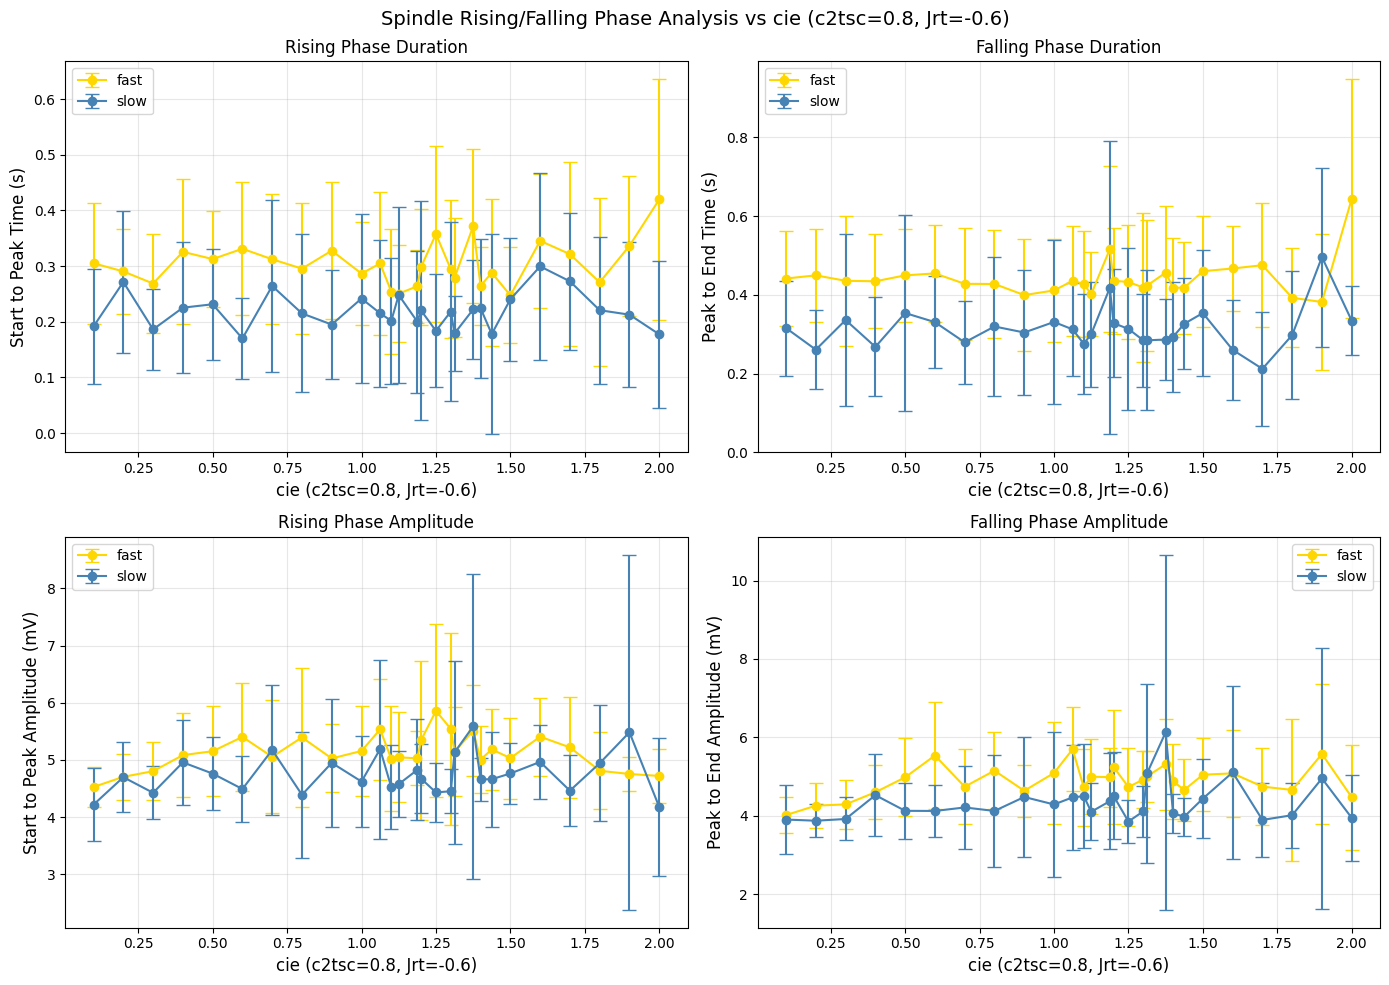


统计摘要（每个 seed 先统计，再对 seed 平均）

FAST 纺锤波:
  cie_c2tsc0x8_Jrt0x6=0.10: seeds=20, count=6.3±1.2, rise_time=0.305±0.109s, fall_time=0.441±0.121s, rise_amp=4.526±0.349mV, fall_amp=4.022±0.452mV, phase=-1.910±1.294rad
  cie_c2tsc0x8_Jrt0x6=0.20: seeds=20, count=6.8±1.4, rise_time=0.290±0.076s, fall_time=0.450±0.118s, rise_amp=4.703±0.404mV, fall_amp=4.261±0.580mV, phase=-2.036±1.370rad
  cie_c2tsc0x8_Jrt0x6=0.30: seeds=20, count=6.5±1.8, rise_time=0.269±0.090s, fall_time=0.436±0.166s, rise_amp=4.803±0.508mV, fall_amp=4.294±0.622mV, phase=-2.031±1.086rad
  cie_c2tsc0x8_Jrt0x6=0.40: seeds=20, count=6.3±2.2, rise_time=0.326±0.130s, fall_time=0.434±0.120s, rise_amp=5.083±0.732mV, fall_amp=4.603±0.685mV, phase=-2.023±1.277rad
  cie_c2tsc0x8_Jrt0x6=0.50: seeds=20, count=6.5±2.0, rise_time=0.313±0.087s, fall_time=0.449±0.118s, rise_amp=5.152±0.788mV, fall_amp=4.983±0.998mV, phase=-2.005±1.307rad
  cie_c2tsc0x8_Jrt0x6=0.60: seeds=20, count=6.2±1.7, rise_time=0.331±0.120s, fall_time=0.454±0.122s, ris

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import circmean, circstd

# ========== 只需要改这一个参数 ==========
PARAM_TYPE = "cie_c2tsc0x8_Jrt0x6"   # 可选: "mue_ext_mean", "tau_ou", "tau_se", "c_gl"
# ======================================

# 根据 PARAM_TYPE 自动生成所有配置
PARAM_CONFIG = {
    "mue_ext_mean": {
        "file": "spindles_mue_ext_mean_explore_valid_limited.csv",
        "xlabel": "mue_ext_mean",
        "save_prefix": "mue_ext_mean",
    },
    "tau_ou": {
        "file": "spindles_tau_ou_explore_valid_limited.csv",
        "xlabel": "tau_ou (ms)",
        "save_prefix": "tau_ou",
    },
    "tau_se": {
        "file": "spindles_tau_se_explore_valid_limited.csv",
        "xlabel": "tau_se (ms)",
        "save_prefix": "tau_se",
    },
    "cee": {
        "file": "spindles_cee_explore_valid_limited.csv",
        "xlabel": "cee",
        "save_prefix": "cee",
    },
    "cie": {
        "file": "spindles_cie_explore_valid_limited.csv",
        "xlabel": "cie",
        "save_prefix": "cie",
    },
    "cie_c2tsc0x8_Jrt0x6": {
        "file": "spindles_cie_c2tsc0x8_Jrt0x6_explore_valid_limited.csv",
        "xlabel": "cie (c2tsc=0.8, Jrt=-0.6)",
        "save_prefix": "cie_c2tsc0x8_Jrt0x6",
    },
}

# 获取当前配置
config = PARAM_CONFIG.get(PARAM_TYPE, PARAM_CONFIG[PARAM_TYPE])
DATA_FILE = config["file"]
X_LABEL = config["xlabel"]
SAVE_PREFIX = config["save_prefix"]
PARAM_NAME = PARAM_TYPE

print(f"加载文件: {DATA_FILE}")
print(f"分析参数: {PARAM_NAME}")

# ========== 以下代码完全不用改 ==========
df = pd.read_csv(f"data/analysis_data/{DATA_FILE}")

# 检查是否有新增的列
new_cols = ['start_to_peak_time', 'peak_to_end_time', 'start_to_peak_amp', 'peak_to_end_amp']
has_new_cols = all(col in df.columns for col in new_cols)
if has_new_cols:
    print(f"检测到新增列: {new_cols}")
else:
    print(f"警告: 未检测到新增列，可能 CSV 未包含 start_to_peak 等字段")

phase_columns = ['phase_at_start', 'phase_at_peak', 'phase_at_end']
phase_labels = ['Start', 'Peak', 'End']
colors = {'fast': 'gold', 'slow': 'steelblue'}

param_values = sorted(df[PARAM_NAME].unique())
print(f"{PARAM_NAME} 值: {param_values}")

def circular_stats(phases):
    if hasattr(phases, 'dropna'):
        phase_clean = phases.dropna().values
    else:
        phase_clean = phases[~np.isnan(phases)]
    if len(phase_clean) == 0:
        return np.nan, np.nan, 0
    mean_phase = circmean(phase_clean, low=-np.pi, high=np.pi)
    std_phase = circstd(phase_clean, low=-np.pi, high=np.pi)
    return mean_phase, std_phase, len(phase_clean)

# ========== 先计算每个 seed 的统计量，再求平均 ==========
# 按参数值和 seed 分组，计算每个 seed 的统计量（包括新的字段）
seed_stats = df.groupby([PARAM_NAME, 'seed', 'type']).agg(
    total_duration=('duration', 'sum'),
    count=('duration', 'size'),
    mean_freq=('frequency', 'mean'),
    std_freq=('frequency', 'std'),
    mean_duration=('duration', 'mean'),
    std_duration=('duration', 'std'),
    # ===== 新增：上升段和下降段的时间与振幅 =====
    mean_start_to_peak_time=('start_to_peak_time', 'mean'),
    std_start_to_peak_time=('start_to_peak_time', 'std'),
    mean_peak_to_end_time=('peak_to_end_time', 'mean'),
    std_peak_to_end_time=('peak_to_end_time', 'std'),
    mean_start_to_peak_amp=('start_to_peak_amp', 'mean'),
    std_start_to_peak_amp=('start_to_peak_amp', 'std'),
    mean_peak_to_end_amp=('peak_to_end_amp', 'mean'),
    std_peak_to_end_amp=('peak_to_end_amp', 'std'),
).reset_index()

# 再按参数值和类型分组，计算所有 seed 的均值和标准差
summary_stats = seed_stats.groupby([PARAM_NAME, 'type']).agg(
    mean_total_duration=('total_duration', 'mean'),
    std_total_duration=('total_duration', 'std'),
    mean_count=('count', 'mean'),
    std_count=('count', 'std'),
    mean_freq=('mean_freq', 'mean'),
    std_freq_mean=('mean_freq', 'std'),
    mean_duration=('mean_duration', 'mean'),
    std_duration_mean=('mean_duration', 'std'),
    # ===== 新增：上升段和下降段的时间与振幅 =====
    mean_start_to_peak_time=('mean_start_to_peak_time', 'mean'),
    std_start_to_peak_time=('mean_start_to_peak_time', 'std'),
    mean_peak_to_end_time=('mean_peak_to_end_time', 'mean'),
    std_peak_to_end_time=('mean_peak_to_end_time', 'std'),
    mean_start_to_peak_amp=('mean_start_to_peak_amp', 'mean'),
    std_start_to_peak_amp=('mean_start_to_peak_amp', 'std'),
    mean_peak_to_end_amp=('mean_peak_to_end_amp', 'mean'),
    std_peak_to_end_amp=('mean_peak_to_end_amp', 'std'),
).reset_index()

print("\n按 seed 统计后的结果示例:")
print(seed_stats.head())
print("\n汇总统计示例:")
print(summary_stats.head())

# ========== 图1：平均相位 ==========
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, (col, label) in enumerate(zip(phase_columns, phase_labels)):
    ax = axes[idx]
    for spindle_type in ['fast', 'slow']:
        subset = df[df['type'] == spindle_type]
        means, stds, vals = [], [], []
        for val in param_values:
            phases = subset[subset[PARAM_NAME] == val][col].dropna().values
            if len(phases) > 0:
                mean_p, std_p, _ = circular_stats(phases)
                means.append(mean_p)
                stds.append(std_p)
                vals.append(val)
        if len(vals) > 0:
            ax.errorbar(vals, means, yerr=stds, fmt='o-', capsize=5,
                        color=colors[spindle_type], label=spindle_type)
    ax.set_xlabel(X_LABEL, fontsize=12)
    ax.set_ylabel('Mean Phase (radians)', fontsize=12)
    ax.set_title(f'Phase at {label}', fontsize=12)
    ax.set_ylim(-np.pi - 0.2, np.pi + 0.2)
    ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
    ax.set_yticklabels(['-π', '-π/2', '0', 'π/2', 'π'])
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
    ax.grid(True, alpha=0.3)
    ax.legend()
plt.suptitle(f'Mean Phase vs {X_LABEL}', fontsize=14)
plt.tight_layout()
plt.show()

# ========== 图2：四张汇总图（数量、频率、时长、总时长）==========
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# 子图1：平均纺锤波数量
ax = axes[0]
for spindle_type in ['fast', 'slow']:
    subset = summary_stats[summary_stats['type'] == spindle_type]
    ax.errorbar(subset[PARAM_NAME], subset['mean_count'], yerr=subset['std_count'],
                fmt='o-', capsize=5, color=colors[spindle_type], label=spindle_type)
ax.set_xlabel(X_LABEL, fontsize=12)
ax.set_ylabel('Mean Number of spindles (per run)', fontsize=12)
ax.set_title('Spindle Count', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# 子图2：平均频率
ax = axes[1]
for spindle_type in ['fast', 'slow']:
    subset = summary_stats[summary_stats['type'] == spindle_type]
    ax.errorbar(subset[PARAM_NAME], subset['mean_freq'], yerr=subset['std_freq_mean'],
                fmt='o-', capsize=5, color=colors[spindle_type], label=spindle_type)
ax.set_xlabel(X_LABEL, fontsize=12)
ax.set_ylabel('Mean Frequency (Hz)', fontsize=12)
ax.set_title('Mean Frequency', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# 子图3：平均时长
ax = axes[2]
for spindle_type in ['fast', 'slow']:
    subset = summary_stats[summary_stats['type'] == spindle_type]
    ax.errorbar(subset[PARAM_NAME], subset['mean_duration'], yerr=subset['std_duration_mean'],
                fmt='o-', capsize=5, color=colors[spindle_type], label=spindle_type)
ax.set_xlabel(X_LABEL, fontsize=12)
ax.set_ylabel('Mean Duration (s)', fontsize=12)
ax.set_title('Mean Duration', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# 子图4：总时长
ax = axes[3]
for spindle_type in ['fast', 'slow']:
    subset = summary_stats[summary_stats['type'] == spindle_type]
    ax.errorbar(subset[PARAM_NAME], subset['mean_total_duration'], yerr=subset['std_total_duration'],
                fmt='o-', capsize=5, color=colors[spindle_type], label=spindle_type)
ax.set_xlabel(X_LABEL, fontsize=12)
ax.set_ylabel('Total Duration (s) per run', fontsize=12)
ax.set_title('Total Duration', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle(f'Spindle Statistics vs {X_LABEL}', fontsize=14)
plt.tight_layout()
plt.show()

# ========== 图3：新增四张子图（上升段时间、下降段时间、上升段振幅、下降段振幅）==========
# 仅在新增列存在时绘制
if has_new_cols:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    # 子图1：上升段时间 (start_to_peak_time)
    ax = axes[0]
    for spindle_type in ['fast', 'slow']:
        subset = summary_stats[summary_stats['type'] == spindle_type]
        ax.errorbar(subset[PARAM_NAME], subset['mean_start_to_peak_time'], 
                    yerr=subset['std_start_to_peak_time'],
                    fmt='o-', capsize=5, color=colors[spindle_type], label=spindle_type)
    ax.set_xlabel(X_LABEL, fontsize=12)
    ax.set_ylabel('Start to Peak Time (s)', fontsize=12)
    ax.set_title('Rising Phase Duration', fontsize=12)
    ax.legend()
    ax.grid(True, alpha=0.3)

    # 子图2：下降段时间 (peak_to_end_time)
    ax = axes[1]
    for spindle_type in ['fast', 'slow']:
        subset = summary_stats[summary_stats['type'] == spindle_type]
        ax.errorbar(subset[PARAM_NAME], subset['mean_peak_to_end_time'], 
                    yerr=subset['std_peak_to_end_time'],
                    fmt='o-', capsize=5, color=colors[spindle_type], label=spindle_type)
    ax.set_xlabel(X_LABEL, fontsize=12)
    ax.set_ylabel('Peak to End Time (s)', fontsize=12)
    ax.set_title('Falling Phase Duration', fontsize=12)
    ax.legend()
    ax.grid(True, alpha=0.3)

    # 子图3：上升段振幅 (start_to_peak_amp)
    ax = axes[2]
    for spindle_type in ['fast', 'slow']:
        subset = summary_stats[summary_stats['type'] == spindle_type]
        ax.errorbar(subset[PARAM_NAME], subset['mean_start_to_peak_amp'], 
                    yerr=subset['std_start_to_peak_amp'],
                    fmt='o-', capsize=5, color=colors[spindle_type], label=spindle_type)
    ax.set_xlabel(X_LABEL, fontsize=12)
    ax.set_ylabel('Start to Peak Amplitude (mV)', fontsize=12)
    ax.set_title('Rising Phase Amplitude', fontsize=12)
    ax.legend()
    ax.grid(True, alpha=0.3)

    # 子图4：下降段振幅 (peak_to_end_amp)
    ax = axes[3]
    for spindle_type in ['fast', 'slow']:
        subset = summary_stats[summary_stats['type'] == spindle_type]
        ax.errorbar(subset[PARAM_NAME], subset['mean_peak_to_end_amp'], 
                    yerr=subset['std_peak_to_end_amp'],
                    fmt='o-', capsize=5, color=colors[spindle_type], label=spindle_type)
    ax.set_xlabel(X_LABEL, fontsize=12)
    ax.set_ylabel('Peak to End Amplitude (mV)', fontsize=12)
    ax.set_title('Falling Phase Amplitude', fontsize=12)
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.suptitle(f'Spindle Rising/Falling Phase Analysis vs {X_LABEL}', fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("\n跳过图3：CSV 中未找到新增列 (start_to_peak_time, peak_to_end_time, start_to_peak_amp, peak_to_end_amp)")

# ========== 打印统计摘要 ==========
print("\n" + "="*60)
print("统计摘要（每个 seed 先统计，再对 seed 平均）")
print("="*60)

for spindle_type in ['fast', 'slow']:
    print(f"\n{spindle_type.upper()} 纺锤波:")
    for val in param_values:
        subset = seed_stats[(seed_stats[PARAM_NAME] == val) & (seed_stats['type'] == spindle_type)]
        if len(subset) > 0:
            n_seeds = len(subset)
            mean_count = subset['count'].mean()
            std_count = subset['count'].std()
            mean_total_dur = subset['total_duration'].mean()
            std_total_dur = subset['total_duration'].std()
            mean_freq = subset['mean_freq'].mean()
            std_freq = subset['mean_freq'].std()
            mean_dur = subset['mean_duration'].mean()
            std_dur = subset['mean_duration'].std()
            
            # 新增统计
            mean_rise_time = subset['mean_start_to_peak_time'].mean() if 'mean_start_to_peak_time' in subset.columns else np.nan
            std_rise_time = subset['mean_start_to_peak_time'].std() if 'mean_start_to_peak_time' in subset.columns else np.nan
            mean_fall_time = subset['mean_peak_to_end_time'].mean() if 'mean_peak_to_end_time' in subset.columns else np.nan
            std_fall_time = subset['mean_peak_to_end_time'].std() if 'mean_peak_to_end_time' in subset.columns else np.nan
            mean_rise_amp = subset['mean_start_to_peak_amp'].mean() if 'mean_start_to_peak_amp' in subset.columns else np.nan
            std_rise_amp = subset['mean_start_to_peak_amp'].std() if 'mean_start_to_peak_amp' in subset.columns else np.nan
            mean_fall_amp = subset['mean_peak_to_end_amp'].mean() if 'mean_peak_to_end_amp' in subset.columns else np.nan
            std_fall_amp = subset['mean_peak_to_end_amp'].std() if 'mean_peak_to_end_amp' in subset.columns else np.nan
            
            # 相位统计（仍用原始数据）
            phases = df[(df[PARAM_NAME] == val) & (df['type'] == spindle_type)]['phase_at_peak'].dropna().values
            if len(phases) > 0:
                mean_phase, std_phase, _ = circular_stats(phases)
                if has_new_cols:
                    print(f"  {PARAM_NAME}={val:.2f}: seeds={n_seeds:2d}, count={mean_count:.1f}±{std_count:.1f}, "
                          f"rise_time={mean_rise_time:.3f}±{std_rise_time:.3f}s, fall_time={mean_fall_time:.3f}±{std_fall_time:.3f}s, "
                          f"rise_amp={mean_rise_amp:.3f}±{std_rise_amp:.3f}mV, fall_amp={mean_fall_amp:.3f}±{std_fall_amp:.3f}mV, "
                          f"phase={mean_phase:6.3f}±{std_phase:.3f}rad")
                else:
                    print(f"  {PARAM_NAME}={val:.2f}: seeds={n_seeds:2d}, count={mean_count:.1f}±{std_count:.1f}, "
                          f"total_dur={mean_total_dur:.2f}±{std_total_dur:.2f}s, freq={mean_freq:.2f}±{std_freq:.2f}Hz, "
                          f"dur={mean_dur:.3f}±{std_dur:.3f}s, phase={mean_phase:6.3f}±{std_phase:.3f}rad")
            else:
                if has_new_cols:
                    print(f"  {PARAM_NAME}={val:.2f}: seeds={n_seeds:2d}, count={mean_count:.1f}±{std_count:.1f}, "
                          f"rise_time={mean_rise_time:.3f}±{std_rise_time:.3f}s, fall_time={mean_fall_time:.3f}±{std_fall_time:.3f}s, "
                          f"rise_amp={mean_rise_amp:.3f}±{std_rise_amp:.3f}mV, fall_amp={mean_fall_amp:.3f}±{std_fall_amp:.3f}mV, "
                          f"no valid phase")
                else:
                    print(f"  {PARAM_NAME}={val:.2f}: seeds={n_seeds:2d}, count={mean_count:.1f}±{std_count:.1f}, "
                          f"total_dur={mean_total_dur:.2f}±{std_total_dur:.2f}s, freq={mean_freq:.2f}±{std_freq:.2f}Hz, "
                          f"dur={mean_dur:.3f}±{std_dur:.3f}s, no valid phase")